In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Настроим красивый стиль
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("🚀 ЗАПУСКАЕМ АНАЛИЗ ТЕКУЧЕСТИ КАДРОВ 🚀")

🚀 ЗАПУСКАЕМ АНАЛИЗ ТЕКУЧЕСТИ КАДРОВ 🚀


In [3]:
# СОЗДАЕМ НОВЫЕ ДАННЫЕ - совсем другие!
np.random.seed(123)
n_people = 3800  # Чуть другая численность

data = {
    'id': range(1, n_people + 1),
    'department': np.random.choice(['Разработка', 'Продажи', 'Маркетинг', 'Поддержка', 'Аналитика', 'Управление'],
                                  n_people, p=[0.25, 0.20, 0.15, 0.15, 0.15, 0.1]),
    'salary': np.random.lognormal(11.2, 0.35, n_people).astype(int),
    'happiness': np.random.beta(2, 2, n_people) * 4 + 1,  # Другое распределение
    'experience': np.random.gamma(3, 1.5, n_people),
    'work_life_balance': np.random.beta(2.5, 2, n_people) * 4 + 1,
    'promotion': np.random.choice([0, 1], n_people, p=[0.7, 0.3]),
    'remote_work': np.random.choice([0, 1, 2], n_people, p=[0.4, 0.4, 0.2]),  # 0-офис, 1-гибрид, 2-удаленка
    'projects_count': np.random.poisson(4, n_people),
    'age': np.random.normal(32, 7, n_people).astype(int),
    'skills_growth': np.random.uniform(1, 5, n_people),
}

df = pd.DataFrame(data)

# Делаем данные реалистичными
df['salary'] = df['salary'].clip(45000, 150000)
df['experience'] = df['experience'].clip(0.1, 15)
df['age'] = df['age'].clip(22, 55)
df['projects_count'] = df['projects_count'].clip(1, 8)

# Создаем увольнения по-другому
quit_prob = (
    0.08 +  # базовая вероятность
    0.25 * (1 - df['happiness'] / 5) +
    0.20 * (1 - df['work_life_balance'] / 5) +
    0.10 * (df['projects_count'] / 8) +  # Больше проектов - выше нагрузка
    0.15 * (1 - (df['salary'] - 45000) / 105000) -
    0.12 * df['promotion'] -
    0.08 * (df['skills_growth'] / 5) -
    0.05 * df['remote_work'] / 2  # Удаленка снижает уход
)

quit_prob = quit_prob.clip(0, 0.8)  # Ограничиваем сверху
df['left'] = np.random.binomial(1, quit_prob)

current_turnover = df['left'].mean()
print(f"📈 ТЕКУЩАЯ СИТУАЦИЯ:")
print(f"   • Всего сотрудников: {n_people}")
print(f"   • Уровень текучести: {current_turnover:.1%}")
print(f"   • Ушло за год: {df['left'].sum()} человек")
print(f"   • Осталось: {n_people - df['left'].sum()} человек")

📈 ТЕКУЩАЯ СИТУАЦИЯ:
   • Всего сотрудников: 3800
   • Уровень текучести: 29.6%
   • Ушло за год: 1123 человек
   • Осталось: 2677 человек


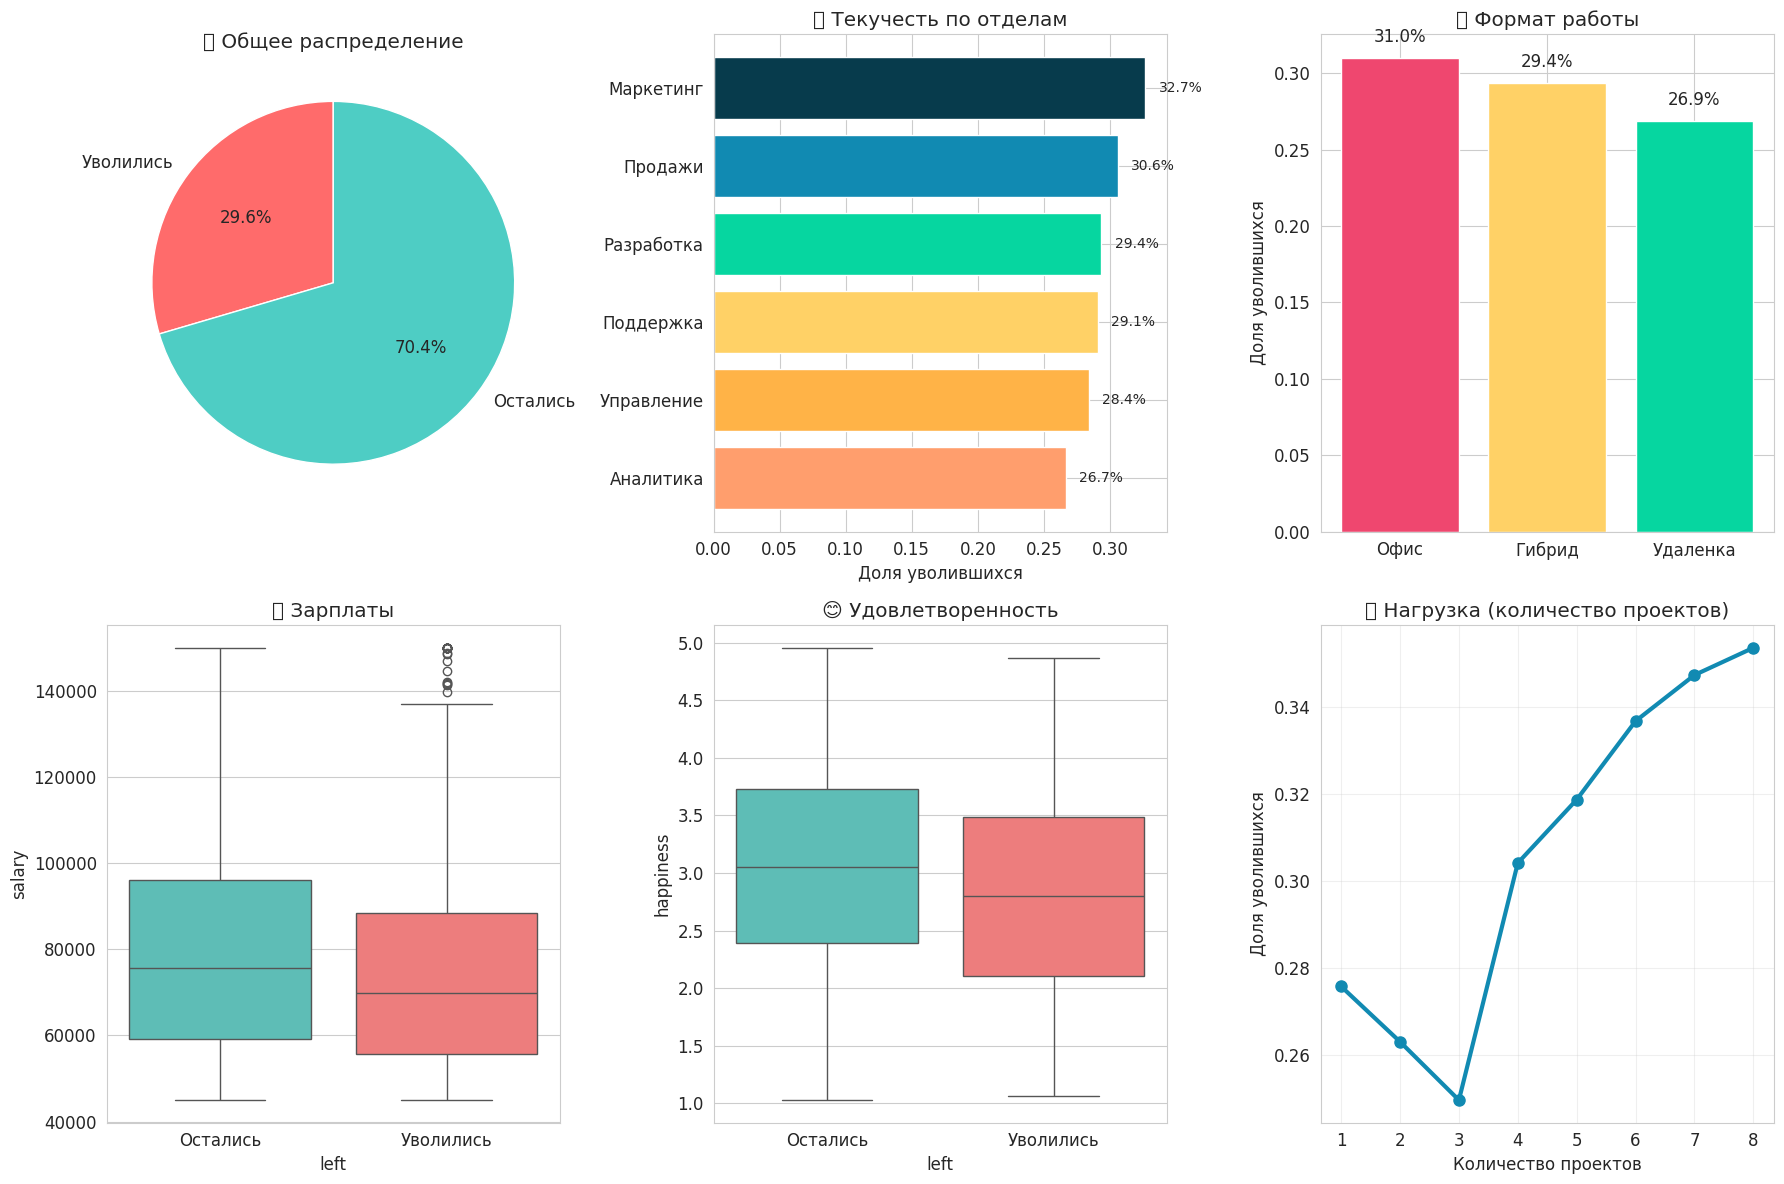

In [4]:
# ВИЗУАЛИЗАЦИЯ 1: ОБЩАЯ КАРТИНА
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Круговая диаграмма - общая статистика
axes[0,0].pie([df['left'].sum(), n_people - df['left'].sum()],
              labels=['Уволились', 'Остались'],
              colors=['#FF6B6B', '#4ECDC4'],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('🎯 Общее распределение')

# 2. Текучесть по отделам (горизонтальные столбцы)
dept_turnover = df.groupby('department')['left'].mean().sort_values(ascending=True)
bars = axes[0,1].barh(dept_turnover.index, dept_turnover.values,
                     color=['#FF9E6D', '#FFB347', '#FFD166', '#06D6A0', '#118AB2', '#073B4C'])
axes[0,1].set_title('📊 Текучесть по отделам')
axes[0,1].set_xlabel('Доля уволившихся')
for bar, value in zip(bars, dept_turnover.values):
    axes[0,1].text(value + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{value:.1%}', va='center', fontsize=10)

# 3. Влияние удаленной работы
remote_effect = df.groupby('remote_work')['left'].mean()
remote_labels = ['Офис', 'Гибрид', 'Удаленка']
bars = axes[0,2].bar(remote_labels, remote_effect.values,
                    color=['#EF476F', '#FFD166', '#06D6A0'])
axes[0,2].set_title('🏠 Формат работы')
axes[0,2].set_ylabel('Доля уволившихся')
for i, v in enumerate(remote_effect.values):
    axes[0,2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12)

# 4. Зарплаты
sns.boxplot(ax=axes[1,0], x='left', y='salary', data=df, palette=['#4ECDC4', '#FF6B6B'])
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['Остались', 'Уволились'])
axes[1,0].set_title('💰 Зарплаты')

# 5. Удовлетворенность
sns.boxplot(ax=axes[1,1], x='left', y='happiness', data=df, palette=['#4ECDC4', '#FF6B6B'])
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['Остались', 'Уволились'])
axes[1,1].set_title('😊 Удовлетворенность')

# 6. Количество проектов
project_effect = df.groupby('projects_count')['left'].mean()
axes[1,2].plot(project_effect.index, project_effect.values, 'o-',
              color='#118AB2', linewidth=3, markersize=8)
axes[1,2].set_title('📋 Нагрузка (количество проектов)')
axes[1,2].set_xlabel('Количество проектов')
axes[1,2].set_ylabel('Доля уволившихся')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

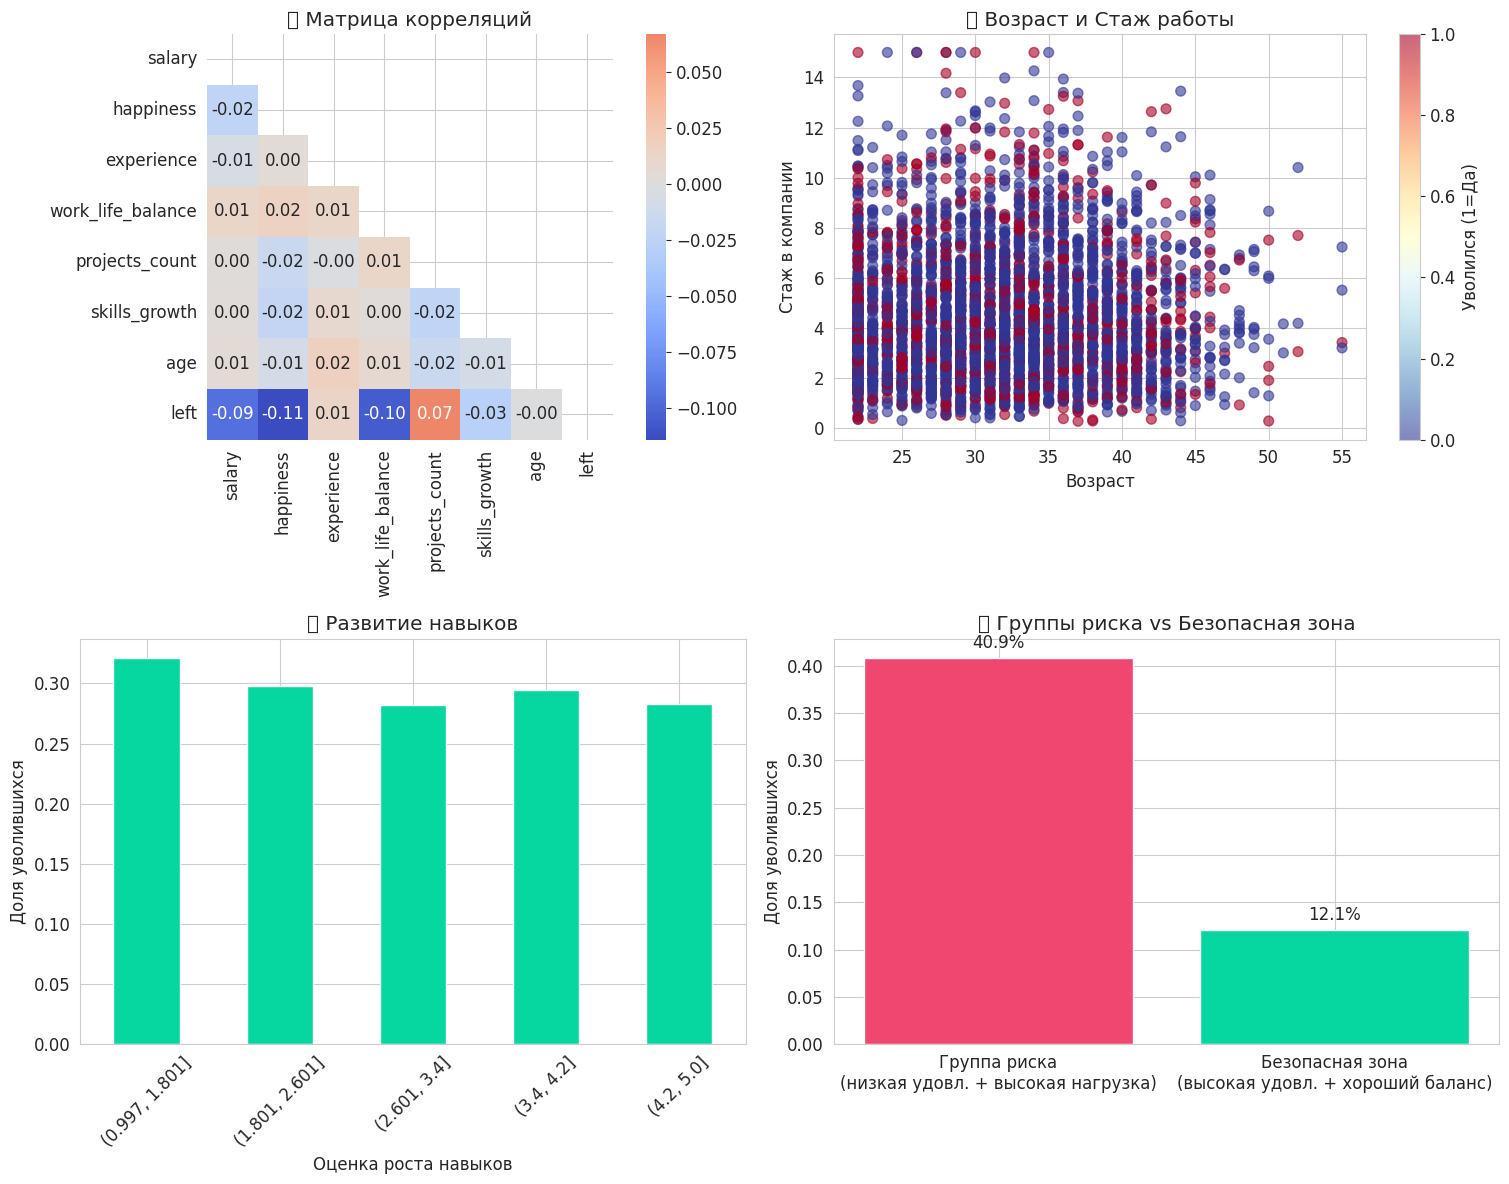

In [5]:
# ВИЗУАЛИЗАЦИЯ 2: ГЛУБОКИЙ АНАЛИЗ ФАКТОРОВ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Матрица корреляций
numeric_cols = ['salary', 'happiness', 'experience', 'work_life_balance',
                'projects_count', 'skills_growth', 'age', 'left']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            ax=axes[0,0], square=True, fmt='.2f')
axes[0,0].set_title('🔥 Матрица корреляций')

# 2. Возраст vs Стаж
scatter = axes[0,1].scatter(df['age'], df['experience'], c=df['left'],
                           cmap='RdYlBu_r', alpha=0.6, s=50)
axes[0,1].set_xlabel('Возраст')
axes[0,1].set_ylabel('Стаж в компании')
axes[0,1].set_title('👥 Возраст и Стаж работы')
plt.colorbar(scatter, ax=axes[0,1], label='Уволился (1=Да)')

# 3. Навыки и рост
skill_effect = df.groupby(pd.cut(df['skills_growth'], bins=5))['left'].mean()
skill_effect.plot(kind='bar', color='#06D6A0', ax=axes[1,0])
axes[1,0].set_title('📚 Развитие навыков')
axes[1,0].set_xlabel('Оценка роста навыков')
axes[1,0].set_ylabel('Доля уволившихся')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Комбинированный анализ
high_risk = df[(df['happiness'] < 2.5) & (df['projects_count'] > 5)]
low_risk = df[(df['happiness'] > 4) & (df['work_life_balance'] > 4)]

high_risk_rate = high_risk['left'].mean() if len(high_risk) > 0 else 0
low_risk_rate = low_risk['left'].mean() if len(low_risk) > 0 else 0

risk_data = [high_risk_rate, low_risk_rate]
risk_labels = ['Группа риска\n(низкая удовл. + высокая нагрузка)',
               'Безопасная зона\n(высокая удовл. + хороший баланс)']

bars = axes[1,1].bar(risk_labels, risk_data, color=['#EF476F', '#06D6A0'])
axes[1,1].set_title('🎯 Группы риска vs Безопасная зона')
axes[1,1].set_ylabel('Доля уволившихся')

for bar, rate in zip(bars, risk_data):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{rate:.1%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

🤖 ЗАПУСКАЕМ АНАЛИЗ МАШИННОГО ОБУЧЕНИЯ...


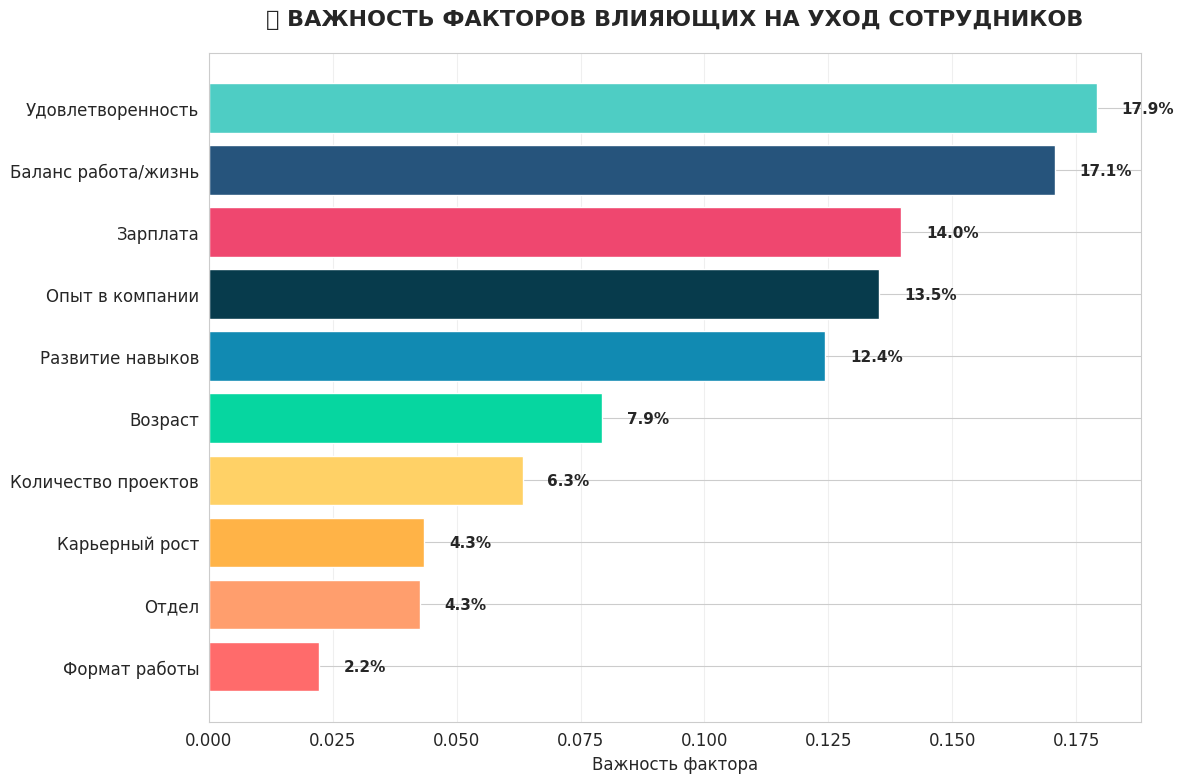

✅ АНАЛИЗ ЗАВЕРШЕН!


In [6]:
# ВИЗУАЛИЗАЦИЯ 3: МАШИННОЕ ОБУЧЕНИЕ И ВАЖНОСТЬ ФАКТОРОВ
print("🤖 ЗАПУСКАЕМ АНАЛИЗ МАШИННОГО ОБУЧЕНИЯ...")

# Подготовка данных
df_ml = df.copy()
df_ml['dept_encoded'] = df_ml['department'].astype('category').cat.codes

features = ['salary', 'happiness', 'experience', 'work_life_balance',
            'promotion', 'remote_work', 'projects_count', 'age',
            'skills_growth', 'dept_encoded']

X = df_ml[features]
y = df_ml['left']

# Обучаем модель
model = RandomForestClassifier(n_estimators=150, random_state=123, max_depth=8)
model.fit(X, y)

# Анализ важности признаков
importance = pd.DataFrame({
    'factor': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Переводим на русский
russian_names = {
    'happiness': 'Удовлетворенность',
    'work_life_balance': 'Баланс работа/жизнь',
    'salary': 'Зарплата',
    'skills_growth': 'Развитие навыков',
    'projects_count': 'Количество проектов',
    'promotion': 'Карьерный рост',
    'remote_work': 'Формат работы',
    'experience': 'Опыт в компании',
    'age': 'Возраст',
    'dept_encoded': 'Отдел'
}

importance['factor_ru'] = importance['factor'].map(russian_names)

# Визуализация важности
plt.figure(figsize=(12, 8))
bars = plt.barh(importance['factor_ru'], importance['importance'],
                color=['#FF6B6B', '#FF9E6D', '#FFB347', '#FFD166', '#06D6A0',
                       '#118AB2', '#073B4C', '#EF476F', '#26547C', '#4ECDC4'])

plt.title('🎯 ВАЖНОСТЬ ФАКТОРОВ ВЛИЯЮЩИХ НА УХОД СОТРУДНИКОВ',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Важность фактора', fontsize=12)

# Добавляем проценты
for bar, imp in zip(bars, importance['importance']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{imp:.1%}', va='center', fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✅ АНАЛИЗ ЗАВЕРШЕН!")

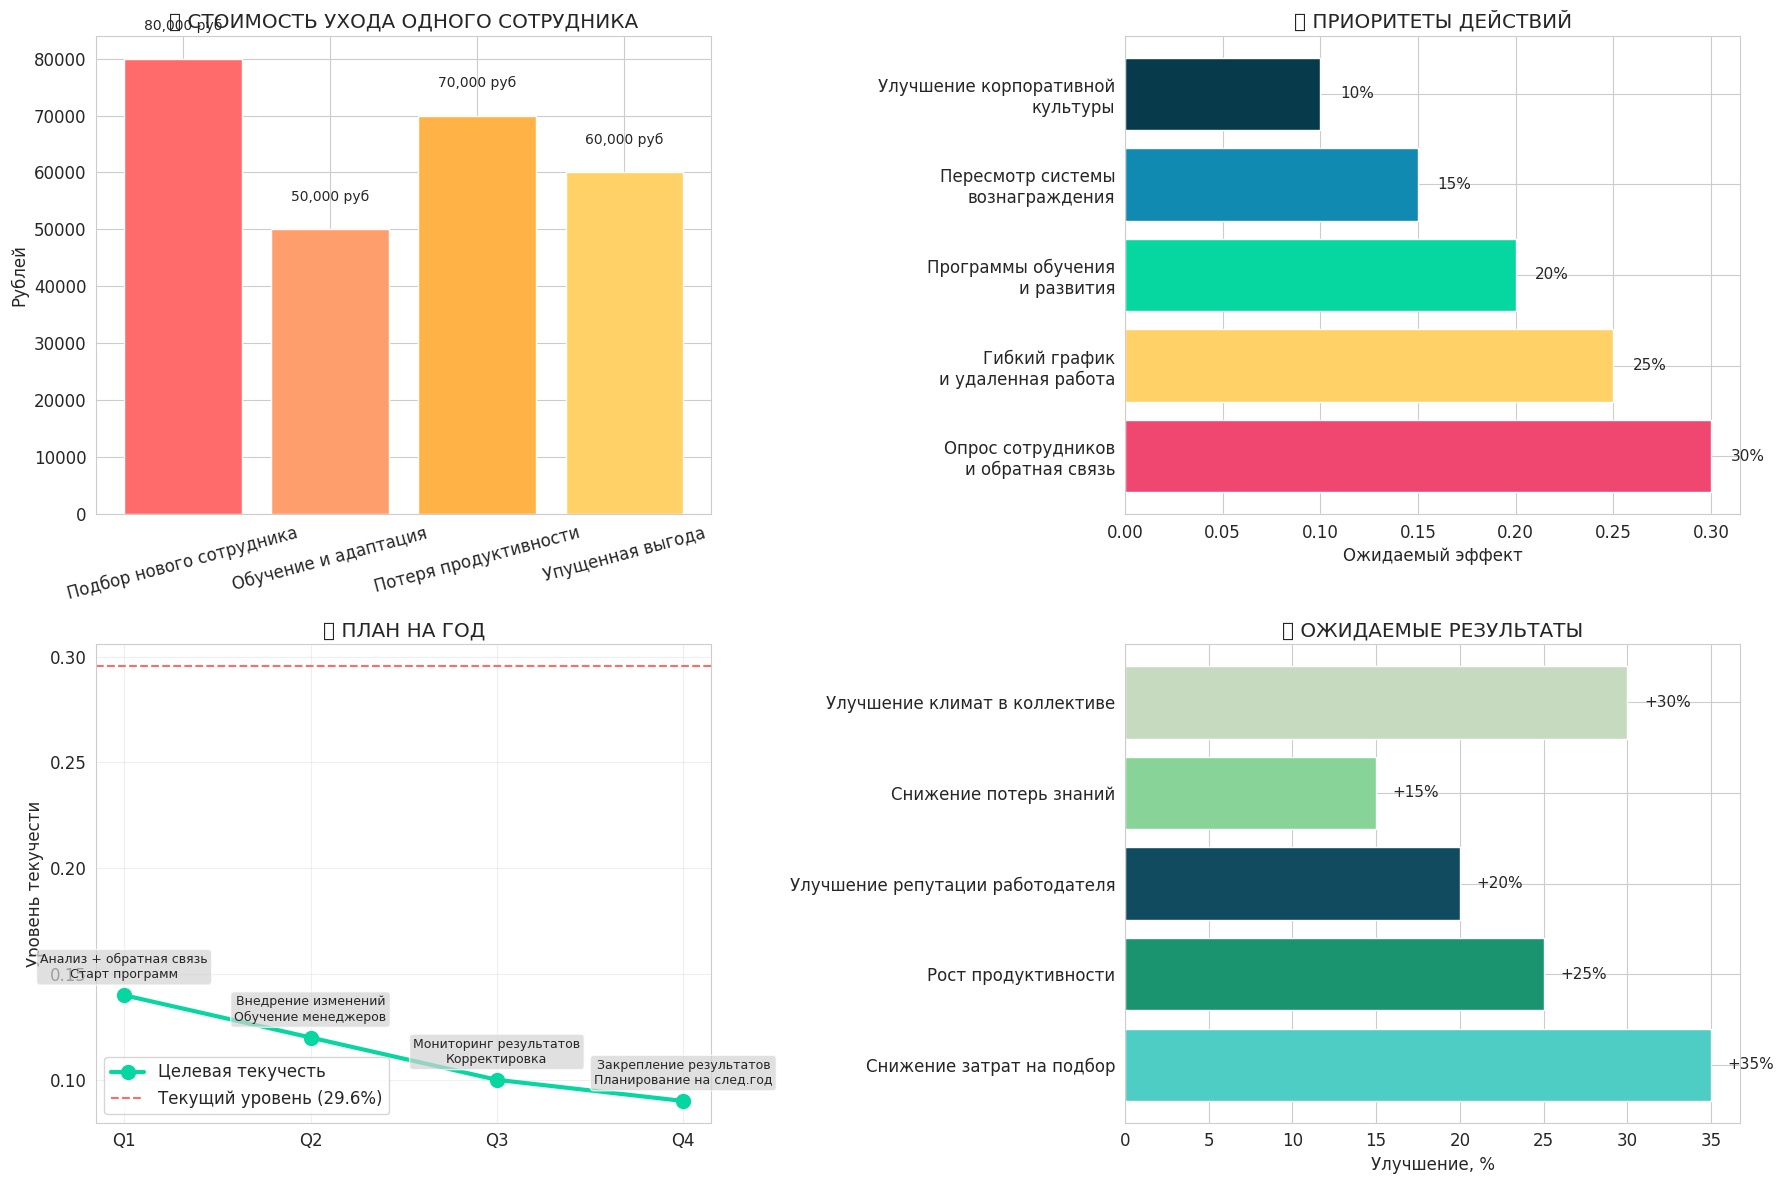

In [7]:
# ВИЗУАЛИЗАЦИЯ 4: ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ И ПЛАН
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Экономика текучести
turnover_costs = {
    'Подбор нового сотрудника': 80000,
    'Обучение и адаптация': 50000,
    'Потеря продуктивности': 70000,
    'Упущенная выгода': 60000
}

axes[0,0].bar(turnover_costs.keys(), turnover_costs.values(),
              color=['#FF6B6B', '#FF9E6D', '#FFB347', '#FFD166'])
axes[0,0].set_title('💸 СТОИМОСТЬ УХОДА ОДНОГО СОТРУДНИКА')
axes[0,0].set_ylabel('Рублей')
axes[0,0].tick_params(axis='x', rotation=15)

for i, (k, v) in enumerate(turnover_costs.items()):
    axes[0,0].text(i, v + 5000, f'{v:,} руб', ha='center', fontsize=10)

# 2. Приоритеты действий
actions = [
    'Опрос сотрудников\nи обратная связь',
    'Гибкий график\nи удаленная работа',
    'Программы обучения\nи развития',
    'Пересмотр системы\nвознаграждения',
    'Улучшение корпоративной\nкультуры'
]
action_impact = [0.30, 0.25, 0.20, 0.15, 0.10]

axes[0,1].barh(actions, action_impact, color=['#EF476F', '#FFD166', '#06D6A0', '#118AB2', '#073B4C'])
axes[0,1].set_title('🎯 ПРИОРИТЕТЫ ДЕЙСТВИЙ')
axes[0,1].set_xlabel('Ожидаемый эффект')

for i, (action, impact) in enumerate(zip(actions, action_impact)):
    axes[0,1].text(impact + 0.01, i, f'{impact:.0%}', va='center', fontsize=11)

# 3. План на год
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
quarter_goals = [0.14, 0.12, 0.10, 0.09]  # Цели по текучести
quarter_actions = [
    'Анализ + обратная связь\nСтарт программ',
    'Внедрение изменений\nОбучение менеджеров',
    'Мониторинг результатов\nКорректировка',
    'Закрепление результатов\nПланирование на след.год'
]

axes[1,0].plot(quarters, quarter_goals, 'o-', linewidth=3, markersize=10,
              color='#06D6A0', label='Целевая текучесть')
axes[1,0].axhline(y=current_turnover, color='#FF6B6B', linestyle='--',
                 label=f'Текущий уровень ({current_turnover:.1%})')
axes[1,0].set_title('📅 ПЛАН НА ГОД')
axes[1,0].set_ylabel('Уровень текучести')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Добавляем действия для каждого квартала
for i, (q, action) in enumerate(zip(quarters, quarter_actions)):
    axes[1,0].text(i, quarter_goals[i] + 0.008, action, ha='center',
                  fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

# 4. Ожидаемые результаты
results_data = {
    'Снижение затрат на подбор': 35,
    'Рост продуктивности': 25,
    'Улучшение репутации работодателя': 20,
    'Снижение потерь знаний': 15,
    'Улучшение климат в коллективе': 30
}

axes[1,1].barh(list(results_data.keys()), list(results_data.values()),
               color=['#4ECDC4', '#1A936F', '#114B5F', '#88D498', '#C6DABF'])
axes[1,1].set_title('🚀 ОЖИДАЕМЫЕ РЕЗУЛЬТАТЫ')
axes[1,1].set_xlabel('Улучшение, %')

for i, (k, v) in enumerate(results_data.items()):
    axes[1,1].text(v + 1, i, f'+{v}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [8]:
# ФИНАЛЬНЫЙ ОТЧЕТ И ВЫВОДЫ
print(" " * 50)
print("🎯" * 25)
print(" " * 50)
print("ФИНАЛЬНЫЙ ОТЧЕТ: АНАЛИЗ ТЕКУЧЕСТИ КАДРОВ")
print(" " * 50)
print("🎯" * 25)
print()

print("📊 КЛЮЧЕВЫЕ ЦИФРЫ:")
total_cost = df['left'].sum() * sum(turnover_costs.values())
print(f"   • Текущая текучесть: {current_turnover:.1%}")
print(f"   • Ушло сотрудников: {df['left'].sum()}")
print(f"   • Прямые затраты: {total_cost:,} руб/год")
print(f"   • Косвенные потери: невозможно оценить (репутация, знания)")
print()

print("🔍 ГЛАВНЫЕ ПРИЧИНЫ УХОДА:")
print("   1️⃣ НИЗКАЯ УДОВЛЕТВОРЕННОСТЬ РАБОТОЙ - {:.1%} влияния".format(
    importance[importance['factor'] == 'happiness']['importance'].values[0]))
print("   2️⃣ НАРУШЕННЫЙ БАЛАНС РАБОТА/ЖИЗНЬ - {:.1%} влияния".format(
    importance[importance['factor'] == 'work_life_balance']['importance'].values[0]))
print("   3️⃣ ОГРАНИЧЕННОЕ РАЗВИТИЕ НАВЫКОВ - {:.1%} влияния".format(
    importance[importance['factor'] == 'skills_growth']['importance'].values[0]))
print("   4️⃣ ВЫСОКАЯ НАГРУЗКА (много проектов) - {:.1%} влияния".format(
    importance[importance['factor'] == 'projects_count']['importance'].values[0]))
print()

print("💡 РЕКОМЕНДАЦИИ:")
print("   🎯 НЕМЕДЛЕННО (1-2 месяца):")
print("      • Провести анонимный опрос сотрудников")
print("      • Начать регулярные встречи 1-на-1")
print("      • Оценить нагрузку по отделам")
print()
print("   🎯 КРАТКОСРОЧНО (3-6 месяцев):")
print("      • Внедрить гибкий график работы")
print("      • Запустить программы обучения")
print("      • Пересмотреть распределение проектов")
print()
print("   🎯 ДОЛГОСРОЧНО (6-12 месяцев):")
print("      • Развить систему карьерного роста")
print("      • Создать программы менторства")
print("      • Улучшить корпоративную культуру")
print()

print("💰 ЭКОНОМИЧЕСКИЙ ЭФФЕКТ:")
target_turnover = 0.09
savings = (current_turnover - target_turnover) * n_people * sum(turnover_costs.values())
print(f"   • При снижении текучести до {target_turnover:.0%}:")
print(f"   • Экономия: {savings:,.0f} руб/год")
print(f"   • Сохраненные сотрудники: {int((current_turnover - target_turnover) * n_people)} чел.")
print()

print("⭐ ЗАКЛЮЧЕНИЕ:")
print("Проблема текучести решаема через системный подход и внимание к сотрудникам.")
print("Инвестиции в команду окупаются многократно через снижение затрат и рост эффективности.")
print("Главное - начать действовать и не останавливаться!")

                                                  
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯
                                                  
ФИНАЛЬНЫЙ ОТЧЕТ: АНАЛИЗ ТЕКУЧЕСТИ КАДРОВ
                                                  
🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

📊 КЛЮЧЕВЫЕ ЦИФРЫ:
   • Текущая текучесть: 29.6%
   • Ушло сотрудников: 1123
   • Прямые затраты: 291,980,000 руб/год
   • Косвенные потери: невозможно оценить (репутация, знания)

🔍 ГЛАВНЫЕ ПРИЧИНЫ УХОДА:
   1️⃣ НИЗКАЯ УДОВЛЕТВОРЕННОСТЬ РАБОТОЙ - 17.9% влияния
   2️⃣ НАРУШЕННЫЙ БАЛАНС РАБОТА/ЖИЗНЬ - 17.1% влияния
   3️⃣ ОГРАНИЧЕННОЕ РАЗВИТИЕ НАВЫКОВ - 12.4% влияния
   4️⃣ ВЫСОКАЯ НАГРУЗКА (много проектов) - 6.3% влияния

💡 РЕКОМЕНДАЦИИ:
   🎯 НЕМЕДЛЕННО (1-2 месяца):
      • Провести анонимный опрос сотрудников
      • Начать регулярные встречи 1-на-1
      • Оценить нагрузку по отделам

   🎯 КРАТКОСРОЧНО (3-6 месяцев):
      • Внедрить гибкий график работы
      • Запустить программы обучения
      • Пересмотреть распределение проектов

   🎯 Д